### **PROYECTO: PREDICCIÓN DE CHURN EN CLIENTES DE SEGUROS**

Objetivo: Identificar qué clientes tienen mayor probabilidad
de abandonar la compañía (churn), para poder intervenir a
tiempo con acciones de retención.

### **Importación de librerías**

In [57]:
import pandas as pd                        # Manejo de datos tabulares
import numpy as np                         # Operaciones numéricas
import matplotlib.pyplot as plt            # Visualizaciones base
import seaborn as sns                      # Visualizaciones estadísticas
from scipy.stats import chi2_contingency   # Test estadístico Chi-cuadrado

In [58]:
# Dimensiones del dataset

# Verificamos cuántos clientes (filas) y cuántas variables
# (columnas) tenemos disponibles para el análisis.
# Esto nos da una primera idea de la escala del problema.
df = pd.read_csv('Train.csv')
df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,labels
0,-0.276515,-0.424429,1.344997,-0.012283,0.076230,1.076648,0.182198,3,0,1,0,0,0,0,10,2,1
1,0.853573,0.150991,0.503892,-0.979179,-0.569351,-0.411453,-0.251940,4,1,2,0,1,0,0,0,3,0
2,0.947747,-0.173832,1.825628,-0.703478,0.076230,-0.411453,-0.251940,6,1,2,0,0,0,0,5,3,0
3,0.853573,-0.381404,0.984523,-0.039464,-0.569351,-0.411453,-0.251940,4,0,2,0,1,0,0,5,3,0
4,1.324443,1.590527,-1.178318,-0.097711,-0.246560,-0.411453,-0.251940,0,1,1,0,0,0,0,8,3,0


In [59]:
print(f"El conjunto de datos cuenta con {df.shape[0]} filas y {df.shape[1]} columnas.")

El conjunto de datos cuenta con 33908 filas y 17 columnas.


In [60]:
# Tipos de datos y valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33908 entries, 0 to 33907
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   feature_0   33908 non-null  float64
 1   feature_1   33908 non-null  float64
 2   feature_2   33908 non-null  float64
 3   feature_3   33908 non-null  float64
 4   feature_4   33908 non-null  float64
 5   feature_5   33908 non-null  float64
 6   feature_6   33908 non-null  float64
 7   feature_7   33908 non-null  int64  
 8   feature_8   33908 non-null  int64  
 9   feature_9   33908 non-null  int64  
 10  feature_10  33908 non-null  int64  
 11  feature_11  33908 non-null  int64  
 12  feature_12  33908 non-null  int64  
 13  feature_13  33908 non-null  int64  
 14  feature_14  33908 non-null  int64  
 15  feature_15  33908 non-null  int64  
 16  labels      33908 non-null  int64  
dtypes: float64(7), int64(10)
memory usage: 4.4 MB


In [61]:
# Distribución del target (variable objetivo)

print("Distribución de la variable objetivo (labels):")
print(df['labels'].value_counts(normalize=True).round(4) * 100)
print("\nPorcentaje global de churn:",
      round(df['labels'].mean() * 100, 2), "%")

Distribución de la variable objetivo (labels):
labels
0    88.3
1    11.7
Name: proportion, dtype: float64

Porcentaje global de churn: 11.7 %


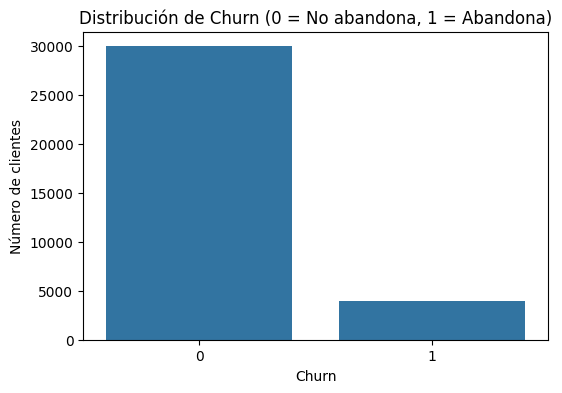

In [62]:
# Visualización del desbalance de clases

# El gráfico confirma visualmente la proporción entre clientes
# que hicieron churn (1) y los que no (0).
# Si el desbalance es significativo (ej: <20% de churn),
# deberemos compensarlo en los modelos con class_weight='balanced'.
plt.figure(figsize=(6, 4))
sns.countplot(x='labels', data=df)
plt.title('Distribución de Churn (0 = No abandona, 1 = Abandona)')
plt.xlabel('Churn')
plt.ylabel('Número de clientes')
plt.show()

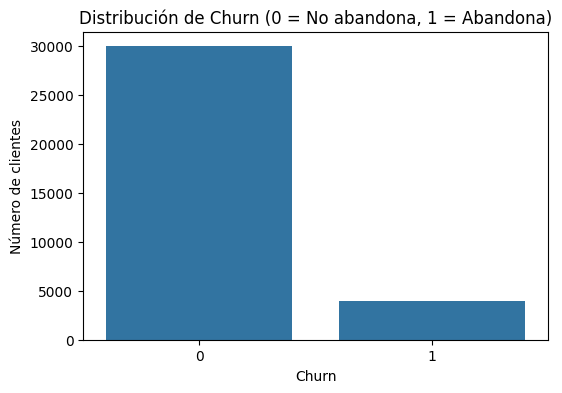

In [63]:
# Visualización del desbalance de clases
plt.figure(figsize=(6, 4))
sns.countplot(x='labels', data=df)
plt.title('Distribución de Churn (0 = No abandona, 1 = Abandona)')
plt.xlabel('Churn')
plt.ylabel('Número de clientes')
plt.show()

In [64]:
# Estadísticas descriptivas de las variables
# Esto nos permite detectar:
#   - Variables con escalas muy distintas (pueden afectar modelos lineales)
#   - Posibles outliers (valores mínimos/máximos extremos)
#   - Variables con poca variabilidad (poco informativas)

print("Resumen estadístico de las variables numéricas:")
num_summary = df.describe()
print(num_summary.round(2).T)

Resumen estadístico de las variables numéricas:
              count  mean   std   min   25%   50%   75%    max
feature_0   33908.0 -0.00  1.00 -2.16 -0.75 -0.18  0.67   5.09
feature_1   33908.0  0.00  1.01 -3.08 -0.42 -0.30  0.02  33.09
feature_2   33908.0 -0.00  1.00 -1.78 -0.94  0.02  0.62   1.83
feature_3   33908.0 -0.00  1.00 -1.00 -0.60 -0.30  0.24  18.09
feature_4   33908.0 -0.00  1.00 -0.57 -0.57 -0.25  0.08  19.44
feature_5   33908.0 -0.00  0.99 -0.41 -0.41 -0.41 -0.41   8.13
feature_6   33908.0 -0.01  0.80 -0.25 -0.25 -0.25 -0.25  23.63
feature_7   33908.0  4.34  3.27  0.00  1.00  4.00  7.00  11.00
feature_8   33908.0  1.17  0.61  0.00  1.00  1.00  2.00   2.00
feature_9   33908.0  1.23  0.75  0.00  1.00  1.00  2.00   3.00
feature_10  33908.0  0.02  0.13  0.00  0.00  0.00  0.00   1.00
feature_11  33908.0  0.56  0.50  0.00  0.00  1.00  1.00   1.00
feature_12  33908.0  0.16  0.37  0.00  0.00  0.00  0.00   1.00
feature_13  33908.0  0.64  0.90  0.00  0.00  0.00  2.00   2.00
feature

In [65]:
# Cardinalidad de las variables

print("Número de valores únicos por variable:")
print(df.nunique().sort_values(ascending=False))

Número de valores únicos por variable:
feature_1     6434
feature_3     1482
feature_5      517
feature_0       77
feature_4       47
feature_6       36
feature_2       31
feature_7       12
feature_14      12
feature_15       4
feature_9        4
feature_8        3
feature_13       3
feature_12       2
feature_11       2
feature_10       2
labels           2
dtype: int64


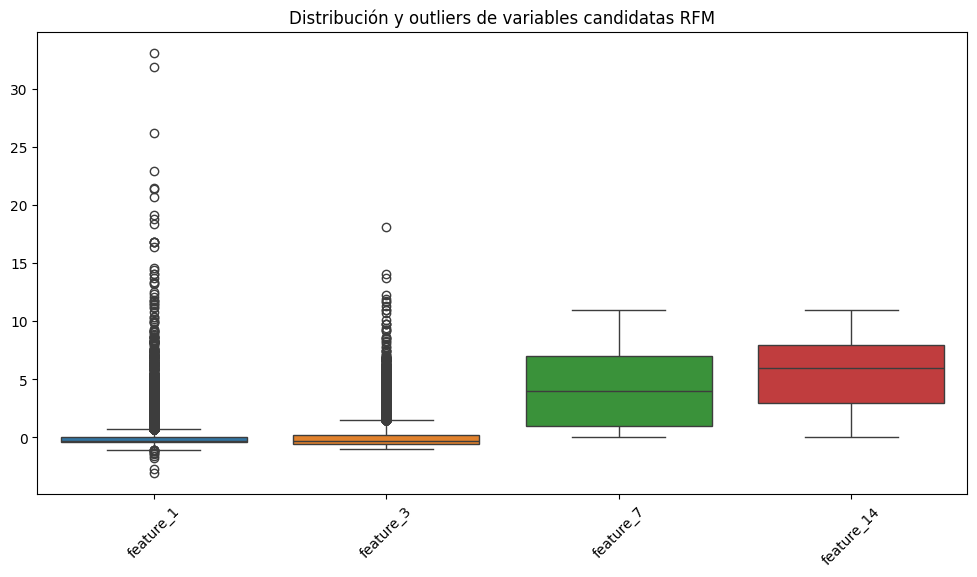

In [66]:
# Detección visual de outliers
# Analizamos las variables candidatas a representar dimensiones
# RFM: Recencia, Frecuencia y Valor Monetario del cliente.

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['feature_1', 'feature_3', 'feature_7', 'feature_14']])
plt.title('Distribución y outliers de variables candidatas RFM')
plt.xticks(rotation=45)
plt.show()

In [67]:
# Construcción de segmentos RFM
# RFM es un framework clásico de análisis de clientes que
# segmenta según tres dimensiones de comportamiento:
#   - R (Recencia): ¿Cuándo fue la última interacción?
#   - F (Frecuencia): ¿Con qué frecuencia interactúa?  → feature_7
#   - M (Monetario): ¿Cuánto valor genera el cliente?  → feature_1

# Cada dimensión se divide en 5 quintiles (1=peor, 5=mejor).
# La combinación F+M genera un "segmento RFM" para cada cliente.
# Usamos rank(method='first') en F para evitar valores duplicados
# que impedirían crear los quintiles correctamente.

df['F_score'] = pd.qcut(df['feature_7'].rank(method='first'),
                         q=5, labels=[1, 2, 3, 4, 5])
df['M_score'] = pd.qcut(df['feature_1'],
                         q=5, labels=[1, 2, 3, 4, 5])
df['RFM_score'] = df['F_score'].astype(str) + df['M_score'].astype(str)

print("Tasa de churn (%) por segmento RFM:")
rfm_churn = (df.groupby('RFM_score')['labels']
               .mean()
               .sort_values(ascending=False) * 100)
print(rfm_churn.round(2))

print("\nNúmero de clientes por segmento RFM:")
print(df['RFM_score'].value_counts().sort_index())

Tasa de churn (%) por segmento RFM:
RFM_score
45    20.78
35    18.78
44    16.51
55    16.29
43    15.44
33    15.17
34    15.10
54    14.16
15    13.34
32    12.76
42    11.93
53    11.73
14    11.55
12    10.66
25    10.34
13     9.49
24     9.43
41     8.67
52     8.60
31     7.37
23     7.26
51     7.09
22     7.00
11     6.50
21     5.66
Name: labels, dtype: float64

Número de clientes por segmento RFM:
RFM_score
11    1462
12    1416
13    1443
14    1299
15    1162
21    1430
22    1443
23    1323
24    1357
25    1228
31    1234
32    1191
33    1266
34    1430
35    1661
41    1292
42    1392
43    1341
44    1351
45    1405
51    1382
52    1325
53    1407
54    1342
55    1326
Name: count, dtype: int64


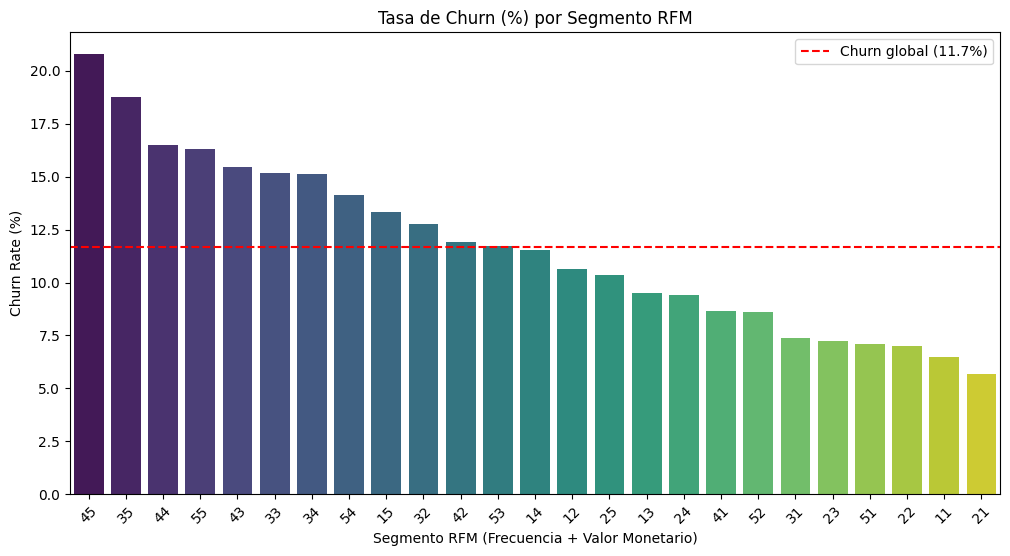

In [68]:
# Visualización del churn por segmento RFM

plt.figure(figsize=(12, 6))
sns.barplot(
    x=rfm_churn.index,
    y=rfm_churn.values,
    hue=rfm_churn.index,
    palette='viridis',
    legend=False
)
plt.title('Tasa de Churn (%) por Segmento RFM')
plt.xlabel('Segmento RFM (Frecuencia + Valor Monetario)')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.axhline(y=df['labels'].mean() * 100,
            color='red', linestyle='--',
            label=f'Churn global ({round(df["labels"].mean()*100,1)}%)')
plt.legend()
plt.show()

In [69]:
# Validación estadística — Test Chi-cuadrado
# El test Chi-cuadrado evalúa si existe una relación real entre
# el segmento RFM y el churn.
#   - p-value < 0.05 → la relación es estadísticamente significativa
#   - p-value ≥ 0.05 → no podemos descartar que sea aleatoria

contingency_table = pd.crosstab(df['RFM_score'], df['labels'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-cuadrado: {chi2:.2f}")
print(f"p-value:      {p_value:.4f}")
print(f"Grados de libertad: {dof}")
print()
if p_value < 0.05:
    print("Conclusión: la relación entre el segmento RFM y el churn "
          "ES estadísticamente significativa (p < 0.05).")
    print("El análisis RFM aporta información real y puede enriquecer el modelo.")
else:
    print("Conclusión: NO se detecta relación estadísticamente significativa "
          "(p ≥ 0.05). El RFM podría no ser útil como feature.")

Chi-cuadrado: 547.94
p-value:      0.0000
Grados de libertad: 24

Conclusión: la relación entre el segmento RFM y el churn ES estadísticamente significativa (p < 0.05).
El análisis RFM aporta información real y puede enriquecer el modelo.


### **PREPARACIÓN DE DATOS Y MODELADO BASE**

In [70]:
# Dividimos el dataset en:
#   - X: las variables de entrada (todo excepto 'labels')
#   - y: la variable que queremos predecir ('labels')

from sklearn.model_selection import train_test_split

X = df.drop(columns=['labels', 'F_score', 'M_score', 'RFM_score'])
y = df['labels']

print(f"Variables de entrada (features): {X.shape[1]}")
print(f"Clientes en el dataset:          {X.shape[0]}")

Variables de entrada (features): 16
Clientes en el dataset:          33908


In [71]:
# División en entrenamiento y validación
# stratify=y garantiza que la proporción de churn (~11.7%) sea
# la misma en ambos subconjuntos, evitando sesgos por muestreo.
# random_state=42 asegura que los resultados sean reproducibles.

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Tamaño Train:      {X_train.shape[0]} clientes")
print(f"Tamaño Validación: {X_val.shape[0]} clientes")
print(f"Churn en Train:    {round(y_train.mean() * 100, 2)}%")
print(f"Churn en Val:      {round(y_val.mean() * 100, 2)}%")
print("La proporción de churn es consistente en ambos subconjuntos.")

Tamaño Train:      27126 clientes
Tamaño Validación: 6782 clientes
Churn en Train:    11.7%
Churn en Val:      11.69%
La proporción de churn es consistente en ambos subconjuntos.


In [72]:
# Entrenamiento del modelo base — Regresión Logística
# Comenzamos con Regresión Logística como modelo base (baseline).
# Si un modelo más complejo no lo supera claramente, no justifica
# su mayor coste computacional ni de interpretabilidad.

from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)
model_lr.fit(X_train, y_train)

print("Modelo de Regresión Logística entrenado correctamente.")
print(f"Entrenado sobre {X_train.shape[0]} clientes.")


Modelo de Regresión Logística entrenado correctamente.
Entrenado sobre 27126 clientes.


In [73]:
# Evaluación del modelo base en validación
# En churn, el Recall suele ser la métrica más crítica:
# no detectar a un cliente que va a abandonar (falso negativo)
# es generalmente más costoso que intervenir con alguien
# que no lo habría hecho (falso positivo).

from sklearn.metrics import classification_report, roc_auc_score

preds_val_lr = model_lr.predict(X_val)
probs_val_lr = model_lr.predict_proba(X_val)[:, 1]

print("── Regresión Logística | Umbral por defecto (0.50) ──")
print(classification_report(y_val, preds_val_lr))
print(f"AUC-ROC: {round(roc_auc_score(y_val, probs_val_lr), 4)}")

── Regresión Logística | Umbral por defecto (0.50) ──
              precision    recall  f1-score   support

           0       0.97      0.82      0.89      5989
           1       0.37      0.79      0.50       793

    accuracy                           0.82      6782
   macro avg       0.67      0.81      0.69      6782
weighted avg       0.90      0.82      0.84      6782

AUC-ROC: 0.8792


In [74]:
# Análisis de umbrales — Curva Precision-Recall
# La curva Precision-Recall muestra el trade-off entre ambas
# métricas para cada posible umbral:
#   - Bajar el umbral → detectamos más churns (↑ Recall)
#                       pero con más falsas alarmas (↓ Precision)
#   - Subir el umbral → mayor precisión, pero nos perdemos
#                       más churns reales (↓ Recall)
#
# Imprimimos varios umbrales para elegir el más adecuado
# según el balance que busca el negocio.

from sklearn.metrics import precision_recall_curve

prec, rec, thresh = precision_recall_curve(y_val, probs_val_lr)

print("Análisis de umbrales — Regresión Logística:")
print(f"{'Umbral':>8} {'Recall':>8} {'Precision':>10} {'F1':>8}")
print("-" * 40)
for t in [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    idx = np.argmin(np.abs(thresh - t))
    f1 = 2 * prec[idx] * rec[idx] / (prec[idx] + rec[idx] + 1e-9)
    print(f"{t:>8.2f} {rec[idx]:>8.3f} {prec[idx]:>10.3f} {f1:>8.3f}")

Análisis de umbrales — Regresión Logística:
  Umbral   Recall  Precision       F1
----------------------------------------
    0.20    0.970      0.192    0.320
    0.25    0.953      0.217    0.354
    0.30    0.934      0.240    0.382
    0.35    0.907      0.267    0.413
    0.40    0.876      0.300    0.447
    0.45    0.832      0.329    0.471
    0.50    0.793      0.367    0.502


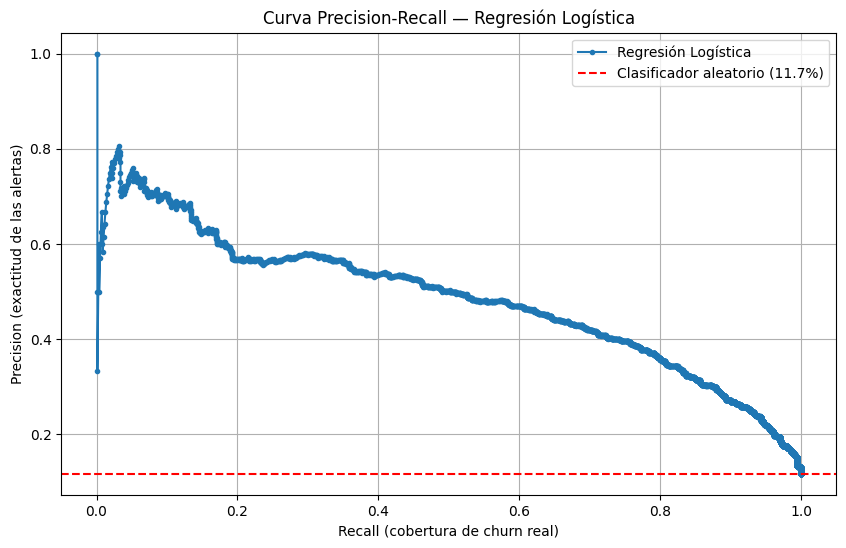

In [75]:
# Visualización de la Curva Precision-Recall
# La línea roja punteada representa el rendimiento de un
# clasificador sin habilidad (predice aleatoriamente según
# la frecuencia base del churn, ~11.7%).
# Cualquier modelo útil debe estar claramente por encima de
# esta línea de referencia en la mayor parte del rango.

plt.figure(figsize=(10, 6))
plt.plot(rec, prec, marker='.', label='Regresión Logística')
plt.xlabel('Recall (cobertura de churn real)')
plt.ylabel('Precision (exactitud de las alertas)')
plt.title('Curva Precision-Recall — Regresión Logística')
plt.grid(True)

no_skill = y_val.mean()
plt.axhline(y=no_skill, color='r', linestyle='--',
            label=f'Clasificador aleatorio ({round(no_skill*100,1)}%)')
plt.legend()
plt.show()

In [76]:
# Selección del umbral óptimo para Regresión Logística

threshold_lr = 0.40
preds_val_lr_opt = (probs_val_lr >= threshold_lr).astype(int)

print(f"── Regresión Logística | Umbral optimizado ({threshold_lr}) ──")
print(classification_report(y_val, preds_val_lr_opt))
print(f"AUC-ROC: {round(roc_auc_score(y_val, probs_val_lr), 4)}")

report_lr = classification_report(y_val, preds_val_lr_opt, output_dict=True)
print("\n📊 Resumen del modelo baseline:")
print(f"   Recall    clase churn (1): {report_lr['1']['recall']:.3f}")
print(f"   Precision clase churn (1): {report_lr['1']['precision']:.3f}")
print(f"   F1-score  clase churn (1): {report_lr['1']['f1-score']:.3f}")
print(f"   AUC-ROC:                   {round(roc_auc_score(y_val, probs_val_lr), 4)}")
print(f"\n   → Este es el BASELINE que debe superar el siguiente modelo.")

── Regresión Logística | Umbral optimizado (0.4) ──
              precision    recall  f1-score   support

           0       0.98      0.73      0.84      5989
           1       0.30      0.88      0.45       793

    accuracy                           0.75      6782
   macro avg       0.64      0.80      0.64      6782
weighted avg       0.90      0.75      0.79      6782

AUC-ROC: 0.8792

📊 Resumen del modelo baseline:
   Recall    clase churn (1): 0.875
   Precision clase churn (1): 0.299
   F1-score  clase churn (1): 0.446
   AUC-ROC:                   0.8792

   → Este es el BASELINE que debe superar el siguiente modelo.


### **MODELO AVANZADO, EVALUACIÓN FINAL Y SUBMISSION**

En esta sección:
   1. Entrenamos un Random Forest con búsqueda de hiperparámetros
      SIN filtración de datos (sin data leakage)
   2. Evaluamos el mejor modelo sobre X_val intacto
   3. Comparamos contra el baseline de Regresión Logística
   4. Analizamos la importancia de las variables
   5. Reentrenamos el modelo final sobre todos los datos
   6. Generamos una única submission justificada
   7. Estimamos el impacto de negocio con supuestos documentados

In [77]:
# Búsqueda de hiperparámetros — Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

param_grid_rf = {
    'n_estimators':      [100, 200],
    'max_depth':         [7, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [2, 4]
}

grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# CRÍTICO: entrenamos SOLO sobre X_train, nunca sobre X o X_val
grid_rf.fit(X_train, y_train)

print("Búsqueda de hiperparámetros completada.")
print(f"   Mejores parámetros: {grid_rf.best_params_}")
print(f"   Mejor AUC en CV (5-fold sobre Train): "
      f"{round(grid_rf.best_score_, 4)}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Búsqueda de hiperparámetros completada.
   Mejores parámetros: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
   Mejor AUC en CV (5-fold sobre Train): 0.9265


In [78]:
# Evaluación del Random Forest en validación

best_rf = grid_rf.best_estimator_

probs_val_rf = best_rf.predict_proba(X_val)[:, 1]
preds_val_rf = best_rf.predict(X_val)

print("── Random Forest | Umbral por defecto (0.50) ──")
print(classification_report(y_val, preds_val_rf))
print(f"AUC-ROC: {round(roc_auc_score(y_val, probs_val_rf), 4)}")

── Random Forest | Umbral por defecto (0.50) ──
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      5989
           1       0.61      0.57      0.59       793

    accuracy                           0.91      6782
   macro avg       0.78      0.76      0.77      6782
weighted avg       0.90      0.91      0.91      6782

AUC-ROC: 0.9278


In [79]:
# Selección del umbral óptimo — Random Forest

prec_rf, rec_rf, thresh_rf = precision_recall_curve(y_val, probs_val_rf)

print("Análisis de umbrales — Random Forest:")
print(f"{'Umbral':>8} {'Recall':>8} {'Precision':>10} {'F1':>8}")
print("-" * 40)
for t in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
    idx = np.argmin(np.abs(thresh_rf - t))
    f1 = 2 * prec_rf[idx] * rec_rf[idx] / (prec_rf[idx] + rec_rf[idx] + 1e-9)
    print(f"{t:>8.2f} {rec_rf[idx]:>8.3f} {prec_rf[idx]:>10.3f} {f1:>8.3f}")

Análisis de umbrales — Random Forest:
  Umbral   Recall  Precision       F1
----------------------------------------
    0.30    0.802      0.496    0.613
    0.35    0.750      0.524    0.617
    0.40    0.690      0.553    0.614
    0.45    0.624      0.588    0.606
    0.50    0.566      0.613    0.589
    0.55    0.472      0.628    0.539
    0.60    0.377      0.657    0.479


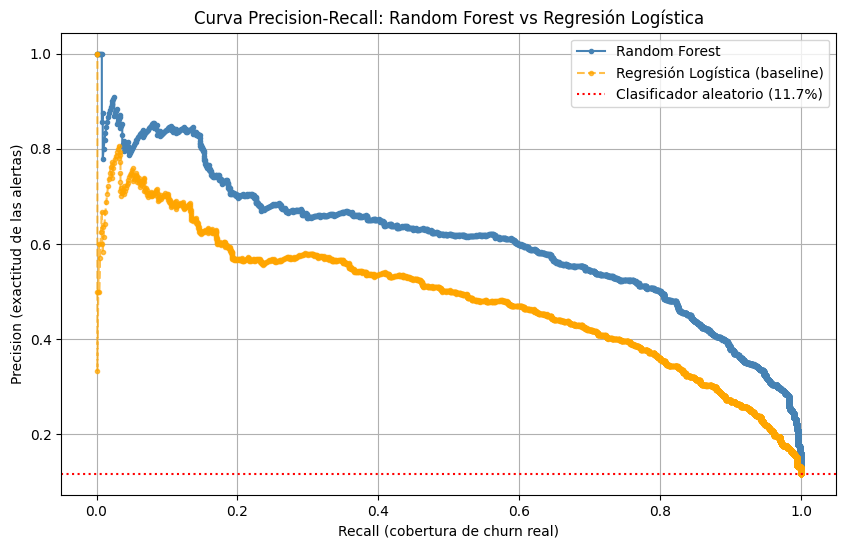

In [80]:
# Visualización Precision-Recall — Random Forest

plt.figure(figsize=(10, 6))
plt.plot(rec_rf, prec_rf, marker='.', label='Random Forest', color='steelblue')
plt.plot(rec, prec, marker='.', label='Regresión Logística (baseline)',
         color='orange', linestyle='--', alpha=0.7)

no_skill = y_val.mean()
plt.axhline(y=no_skill, color='red', linestyle=':',
            label=f'Clasificador aleatorio ({round(no_skill*100,1)}%)')

plt.xlabel('Recall (cobertura de churn real)')
plt.ylabel('Precision (exactitud de las alertas)')
plt.title('Curva Precision-Recall: Random Forest vs Regresión Logística')
plt.grid(True)
plt.legend()
plt.show()

### **Comparación formal de modelos**

 Antes de declarar un ganador, comparamos ambos modelos con
 el mismo umbral para que la comparación sea justa.
 Documentamos explícitamente las métricas clave de cada uno.

 El modelo seleccionado debe superar al baseline en AUC-ROC
 y en F1 de la clase churn. Si la diferencia es marginal,
 la Regresión Logística sería preferible por su mayor
 interpretabilidad y menor coste computacional.

In [81]:
threshold_rf = 0.40
preds_val_rf_opt = (probs_val_rf >= threshold_rf).astype(int)
report_rf = classification_report(y_val, preds_val_rf_opt, output_dict=True)
report_lr = classification_report(y_val, preds_val_lr_opt, output_dict=True)

print("━" * 50)
print(f"{'Métrica':<30} {'Log. Reg.':>9} {'Rand. Forest':>12}")
print("━" * 50)
print(f"{'AUC-ROC':<30}"
      f"{round(roc_auc_score(y_val, probs_val_lr), 4):>9}"
      f"{round(roc_auc_score(y_val, probs_val_rf), 4):>12}")
print(f"{'Recall clase churn (1)':<30}"
      f"{report_lr['1']['recall']:>9.3f}"
      f"{report_rf['1']['recall']:>12.3f}")
print(f"{'Precision clase churn (1)':<30}"
      f"{report_lr['1']['precision']:>9.3f}"
      f"{report_rf['1']['precision']:>12.3f}")
print(f"{'F1-score clase churn (1)':<30}"
      f"{report_lr['1']['f1-score']:>9.3f}"
      f"{report_rf['1']['f1-score']:>12.3f}")
print("━" * 50)

auc_lr = roc_auc_score(y_val, probs_val_lr)
auc_rf = roc_auc_score(y_val, probs_val_rf)
ganador = "Random Forest" if auc_rf > auc_lr else "Regresión Logística"
print(f" Modelo seleccionado: {ganador}")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Métrica                        Log. Reg. Rand. Forest
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
AUC-ROC                          0.8792      0.9278
Recall clase churn (1)            0.875       0.690
Precision clase churn (1)         0.299       0.553
F1-score clase churn (1)          0.446       0.614
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Modelo seleccionado: Random Forest


### **Importancia de variables — Random Forest**

 Una ventaja del Random Forest es que mide la contribución
 de cada variable a las predicciones del modelo.
 Las variables más importantes son aquellas cuya presencia
 reduce más la impureza (incertidumbre) en los árboles.

 Este análisis responde preguntas de negocio clave:
   ¿Qué comportamientos del cliente predicen mejor el churn?
   ¿En qué variables debería enfocarse la estrategia de retención?


Top 10 variables más importantes para predecir churn:
feature_3     0.4014
feature_14    0.0843
feature_1     0.0764
feature_0     0.0731
feature_2     0.0669
feature_13    0.0487
feature_5     0.0482
feature_15    0.0378
feature_11    0.0358
feature_7     0.0331
dtype: float64


C:\Users\Marco\AppData\Local\Temp\ipykernel_37088\297564368.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values[:10], y=importances.index[:10],


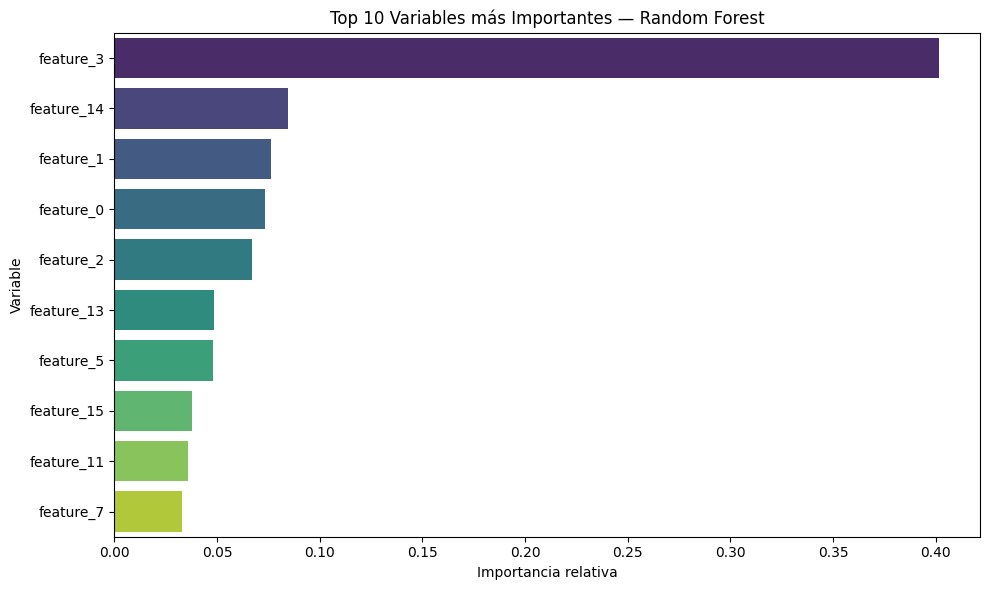

In [82]:
importances = (pd.Series(best_rf.feature_importances_, index=X_train.columns)
                 .sort_values(ascending=False))

print("Top 10 variables más importantes para predecir churn:")
print(importances.head(10).round(4))

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values[:10], y=importances.index[:10],
            palette='viridis')
plt.title('Top 10 Variables más Importantes — Random Forest')
plt.xlabel('Importancia relativa')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

In [87]:
# Reentrenamiento del modelo final

model_final = RandomForestClassifier(
    **grid_rf.best_params_,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model_final.fit(X, y)

print("Modelo final reentrenado sobre el 100% del conjunto Train.")
print(f"   Hiperparámetros usados: {grid_rf.best_params_}")
print(f"   Clientes usados para entrenamiento final: {X.shape[0]}")

Modelo final reentrenado sobre el 100% del conjunto Train.
   Hiperparámetros usados: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
   Clientes usados para entrenamiento final: 33908


In [84]:
# Generación de predicciones sobre Test

test = pd.read_csv('Test.csv')

probs_test = model_final.predict_proba(test)[:, 1]
preds_test = (probs_test >= threshold_rf).astype(int)

print("Predicciones generadas para Test.csv:")
dist = pd.Series(preds_test).value_counts(normalize=True).round(3) * 100
print(f"   Clientes sin churn (0): {dist.get(0, 0):.1f}%")
print(f"   Clientes con churn (1): {dist.get(1, 0):.1f}%")
print(f"   Total clientes en Test: {len(preds_test)}")


Predicciones generadas para Test.csv:
   Clientes sin churn (0): 84.8%
   Clientes con churn (1): 15.2%
   Total clientes en Test: 11303


### **Creación del archivo de submission**

Generamos el archivo final de entrega siguiendo la estructura
del sample_submission.xlsx proporcionado por la competición.

 Se genera UN ÚNICO archivo de submission correspondiente al
 modelo ganador (Random Forest, umbral 0.40), evitando la
 confusión de múltiples archivos con distintos criterios.

 El nombre del archivo documenta el modelo y el umbral usado
 para facilitar la trazabilidad del resultado.

In [85]:
import os

# Creamos el DataFrame base con las predicciones
submission = pd.DataFrame({'labels': preds_test})

# Intentamos cargar el sample para recuperar columna de IDs
sample_xlsx = 'sample_submission.xlsx'
sample_csv  = 'sample_submission.csv'

if os.path.exists(sample_xlsx):
    sample = pd.read_excel(sample_xlsx)
    print(f"Sample encontrado: {sample_xlsx}")
    if 'ID' in sample.columns:
        submission.insert(0, 'ID', sample['ID'])
    elif len(sample) == len(preds_test):
        submission.index = sample.index

elif os.path.exists(sample_csv):
    sample = pd.read_csv(sample_csv)
    print(f"Sample encontrado: {sample_csv}")
    if 'ID' in sample.columns:
        submission.insert(0, 'ID', sample['ID'])
    elif len(sample) == len(preds_test):
        submission.index = sample.index

else:
    print("   No se encontró archivo sample_submission.")
    print("   Se genera submission solo con predicciones.")
    print("   Si la plataforma requiere columna ID, añádela manualmente.")

# Guardamos el archivo final
nombre_archivo = f'submission_rf_umbral{threshold_rf}.csv'
submission.to_csv(nombre_archivo, index=False)

print(f"\  Archivo de submission creado: {nombre_archivo}")
print(f"   Modelo:  Random Forest (hiperparámetros optimizados)")
print(f"   Umbral:  {threshold_rf}")
print(f"   Filas:   {len(submission)}")
print("\nPrimeras 10 filas del archivo:")
print(submission.head(10))

   No se encontró archivo sample_submission.
   Se genera submission solo con predicciones.
   Si la plataforma requiere columna ID, añádela manualmente.
\  Archivo de submission creado: submission_rf_umbral0.4.csv
   Modelo:  Random Forest (hiperparámetros optimizados)
   Umbral:  0.4
   Filas:   11303

Primeras 10 filas del archivo:
   labels
0       1
1       0
2       0
3       0
4       0
5       0
6       0
7       0
8       1
9       0


<>:35: SyntaxWarning: invalid escape sequence '\ '
<>:35: SyntaxWarning: invalid escape sequence '\ '
C:\Users\Marco\AppData\Local\Temp\ipykernel_37088\3774323184.py:35: SyntaxWarning: invalid escape sequence '\ '
  print(f"\  Archivo de submission creado: {nombre_archivo}")


### **ESTIMACIÓN DEL IMPACTO DE NEGOCIO**

 Traducimos los resultados del modelo a términos económicos
 para comunicar su valor al negocio.

 SUPUESTOS (deben ser validados con el equipo de negocio):
   - Costo de intervención por cliente: $50
     (llamada de retención, descuento, gestor asignado)
   - Valor evitado por churn retenido: $500
     (LTV medio del cliente o prima anual estimada)
   - Precision estimada: tomada del reporte en X_val
   - Recall estimado: tomado del reporte en X_val

 LIMITACIÓN IMPORTANTE: estas cifras son orientativas.
 El impacto real dependerá de la tasa de éxito de las
 intervenciones, que este modelo no puede predecir.


In [86]:
costo_intervencion   = 50     # $ por cliente contactado
valor_churn_evitado  = 500    # $ por churn retenido exitosamente

precision_val = report_rf['1']['precision']
recall_val    = report_rf['1']['recall']

n_alertas          = int(preds_test.sum())
churns_detectables = int(n_alertas * precision_val)
costo_total        = n_alertas * costo_intervencion
ahorro_bruto       = churns_detectables * valor_churn_evitado
ahorro_neto        = ahorro_bruto - costo_total
roi                = (ahorro_neto / costo_total) * 100 if costo_total > 0 else 0

print("━" * 50)
print("  ESTIMACIÓN DE IMPACTO DE NEGOCIO")
print("━" * 50)
print(f"  Clientes alertados (predichos churn):  {n_alertas:>6}")
print(f"  Churns reales estimados entre ellos:   {churns_detectables:>6}")
print(f"  Costo total de intervenciones:        ${costo_total:>8,.0f}")
print(f"  Ahorro bruto estimado:                ${ahorro_bruto:>8,.0f}")
print(f"  Ahorro neto estimado:                 ${ahorro_neto:>8,.0f}")
print(f"  ROI estimado:                          {roi:>6.0f}%")
print("━" * 50)
print(f"  Supuestos: intervención=${costo_intervencion}$, "
      f"valor retenido=${valor_churn_evitado}$")
print(f"   Precision en validación: {precision_val:.3f} | "
      f"Recall en validación: {recall_val:.3f}")
print("\Estas cifras son orientativas. Se recomienda un test")
print("   A/B controlado antes de escalar la estrategia.")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ESTIMACIÓN DE IMPACTO DE NEGOCIO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Clientes alertados (predichos churn):    1723
  Churns reales estimados entre ellos:      952
  Costo total de intervenciones:        $  86,150
  Ahorro bruto estimado:                $ 476,000
  Ahorro neto estimado:                 $ 389,850
  ROI estimado:                             453%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Supuestos: intervención=$50$, valor retenido=$500$
   Precision en validación: 0.553 | Recall en validación: 0.690
\Estas cifras son orientativas. Se recomienda un test
   A/B controlado antes de escalar la estrategia.


<>:28: SyntaxWarning: invalid escape sequence '\E'
<>:28: SyntaxWarning: invalid escape sequence '\E'
C:\Users\Marco\AppData\Local\Temp\ipykernel_37088\1861550207.py:28: SyntaxWarning: invalid escape sequence '\E'
  print("\Estas cifras son orientativas. Se recomienda un test")
